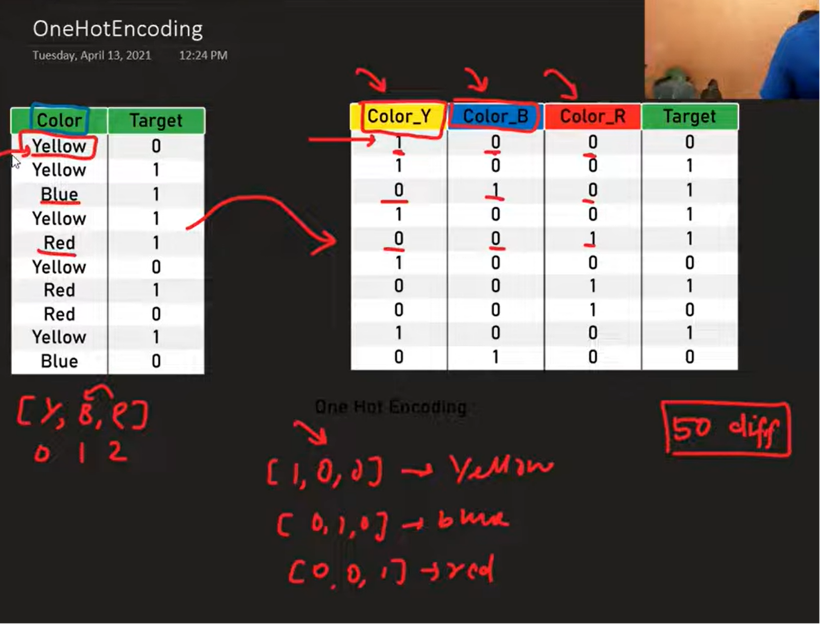

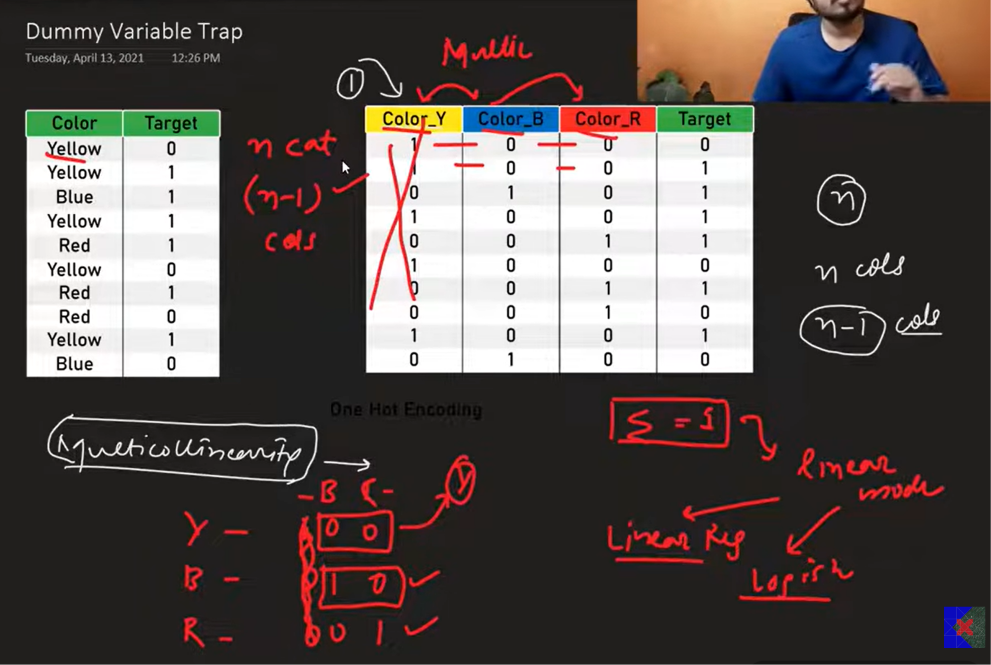

`dummy vairable trap`  is occured during the nominal encoding when we make multiple input column like in left side dataset there are two column color and target but for encoding we make n extra column where n is the number of categories.

`dummy variable ` is the extra column which is written right side named color_y,color_b,color_r


due to dummy variable there is a problem occur which is called  `Multicollinaerity`  


`multicollinearity `  means  in machine learnign the input column should be independent of each other but in case of dummy variable like in this case there is mathematical dependecies among input column color_y,color_B,color_r which the sum of all columns is 1.


solution of multicollinearity

we create n-1 columns where n is the number of categorries

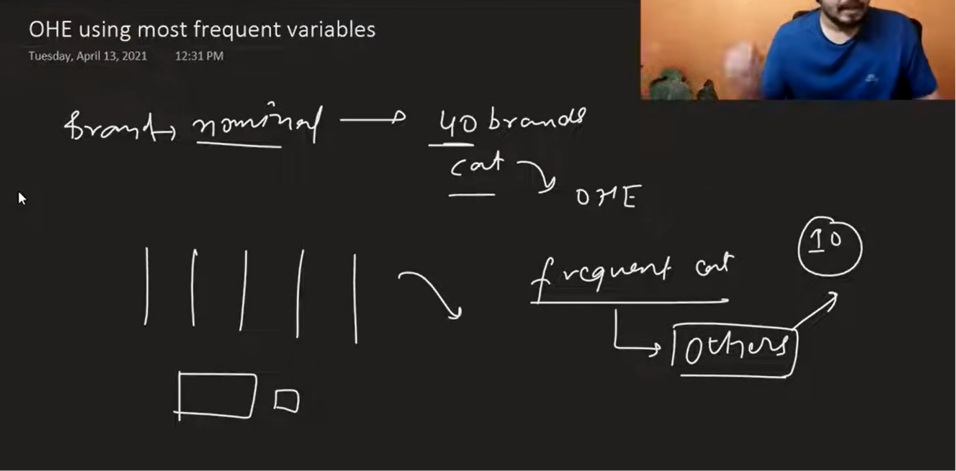

in case of many number of categories the number of variable is more which make data more complex to process or it increases the dimension of dataset 

hence we use onyl most frequent catoreies as variable and those categories which less frequency are categories in other category like others



### Example


In [1]:
import pandas as pd


In [2]:
df=pd.read_csv('dataset/cars.csv')

In [3]:
df.sample(5)

,brand,km_driven,fuel,owner,selling_price
7549,Maruti,76000,Petrol,First Owner,150000
845,Ford,70000,Petrol,Second Owner,200000
7938,Hyundai,40000,Diesel,First Owner,1200000
7842,Honda,100000,Diesel,Second Owner,450000
318,Toyota,160000,Diesel,Second Owner,800000


In [4]:
# lets chek the number of categories in brand
df['brand'].nunique()

32

#### there are 32 different catogries of brand itself it mean if we apply one hot encoding then we get 32 addition columns

In [5]:
# lets check the number of categories of fuel aand owner

print(df['fuel'].nunique(),df['owner'].nunique())


4 5


that is 4 and 5 categories of fuel and owener

In [6]:
df['fuel'].value_counts()

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

### one hot encoding using pandas

In [11]:
pd.get_dummies(df,columns=['fuel','owner'])

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,False,True,False,False,True,False,False,False,False
1,Skoda,120000,370000,False,True,False,False,False,False,True,False,False
2,Honda,140000,158000,False,False,False,True,False,False,False,False,True
3,Hyundai,127000,225000,False,True,False,False,True,False,False,False,False
4,Maruti,120000,130000,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,False,True,True,False,False,False,False
8124,Hyundai,119000,135000,False,True,False,False,False,True,False,False,False
8125,Maruti,120000,382000,False,True,False,False,True,False,False,False,False
8126,Tata,25000,290000,False,True,False,False,True,False,False,False,False


here we left `brand ` because in that columns there are many categories hence there are a large number variable column we will see it later

in above example the encoding in true false but we have do it in 0 and 1

In [13]:
pd.get_dummies(df,columns=['fuel','owner'],dtype=int)

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,0,1,0,0,1,0,0,0,0
1,Skoda,120000,370000,0,1,0,0,0,0,1,0,0
2,Honda,140000,158000,0,0,0,1,0,0,0,0,1
3,Hyundai,127000,225000,0,1,0,0,1,0,0,0,0
4,Maruti,120000,130000,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,0,1,1,0,0,0,0
8124,Hyundai,119000,135000,0,1,0,0,0,1,0,0,0
8125,Maruti,120000,382000,0,1,0,0,1,0,0,0,0
8126,Tata,25000,290000,0,1,0,0,1,0,0,0,0


but above example it doesnot solve the problem of `multicollinearity` 

lets solvd the problem of `multicollinearty`

### k-1 one hot encoding

In [16]:
pd.get_dummies(df,columns=['fuel','owner'],dtype=int,drop_first=True)

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,1,0,0,0,0,0,0
1,Skoda,120000,370000,1,0,0,0,1,0,0
2,Honda,140000,158000,0,0,1,0,0,0,1
3,Hyundai,127000,225000,1,0,0,0,0,0,0
4,Maruti,120000,130000,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,1,0,0,0,0
8124,Hyundai,119000,135000,1,0,0,1,0,0,0
8125,Maruti,120000,382000,1,0,0,0,0,0,0
8126,Tata,25000,290000,1,0,0,0,0,0,0


now we can see that from each column one categories gets droped

##### while using data analysis we use padnas for one hot encoding but during ml project we cant implement this method because it does not remember the place if we generate another time it gives different output 

In [21]:
df.sample(4)

,brand,km_driven,fuel,owner,selling_price
4986,Maruti,10000,Petrol,First Owner,500000
5461,Maruti,39000,Petrol,Third Owner,380000
3896,Maruti,25000,Petrol,Second Owner,411000
2951,Maruti,170000,Diesel,First Owner,355000


In [24]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(df.iloc[:,0:4],df['selling_price'],
                                               test_size=0.2,
                                               random_state=1
                                               )

In [25]:
x_train

,brand,km_driven,fuel,owner
1939,Honda,100000,Diesel,Second Owner
5455,Maruti,120000,Diesel,Second Owner
7079,Renault,100000,Diesel,Second Owner
2000,Honda,80000,Petrol,Second Owner
1578,Honda,56494,Petrol,First Owner
...,...,...,...,...
7935,Maruti,100000,Petrol,Third Owner
5192,Hyundai,152000,Diesel,First Owner
3980,Hyundai,70000,Petrol,First Owner
235,Maruti,110000,Diesel,Second Owner


In [31]:
# now apply one hot encodin
import numpy as np

from sklearn.preprocessing import OneHotEncoder

ohe=OneHotEncoder()

x_train_enconded=ohe.fit_transform(x_train[['fuel','owner']]).toarray()  # it returns a sparse matrix
x_test_encoded=ohe.transform(x_test[['fuel','owner']]).toarray()

x_train_enconded





array([[0., 1., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6502, 9))

now here there are some problem like  dtype is float and also there is problem of `multicolinearty`   which can be solved using follwing way 

and also if do sparse =false then we dont need to convert it innto array

In [37]:
from sklearn.preprocessing import OneHotEncoder

ohe=OneHotEncoder(drop='first',dtype=np.int32)


x_train_enconded=ohe.fit_transform(x_train[['fuel','owner']]).toarray() # it returns a sparse matrix
x_test_encoded=ohe.transform(x_test[['fuel','owner']]).toarray()

x_train_enconded

array([[1, 0, 0, ..., 1, 0, 0],
       [1, 0, 0, ..., 1, 0, 0],
       [1, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 1, ..., 0, 0, 0],
       [1, 0, 0, ..., 1, 0, 0],
       [0, 0, 1, ..., 0, 0, 0]], shape=(6502, 7), dtype=int32)

as we can see that number of column decreases

#### now we have to add those brand and km_driven column 

In [42]:
x_train[['brand','km_driven']]

,brand,km_driven
1939,Honda,100000
5455,Maruti,120000
7079,Renault,100000
2000,Honda,80000
1578,Honda,56494
...,...,...
7935,Maruti,100000
5192,Hyundai,152000
3980,Hyundai,70000
235,Maruti,110000


In [43]:
# to chagne to in numpy array 

x_train[['brand','km_driven']].values

array([['Honda', 100000],
       ['Maruti', 120000],
       ['Renault', 100000],
       ...,
       ['Hyundai', 70000],
       ['Maruti', 110000],
       ['Maruti', 65755]], shape=(6502, 2), dtype=object)

In [47]:
x_train_enconded

array([[1, 0, 0, ..., 1, 0, 0],
       [1, 0, 0, ..., 1, 0, 0],
       [1, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 1, ..., 0, 0, 0],
       [1, 0, 0, ..., 1, 0, 0],
       [0, 0, 1, ..., 0, 0, 0]], shape=(6502, 7), dtype=int32)

In [48]:
# lets add thsi 

np.hstack((x_train[['brand','km_driven']].values,x_train_enconded)).shape

(6502, 9)

### One hot encoding with most frequestn categories

In [52]:
# lets talk abut brand

df['brand'].value_counts()

brand
Maruti           2448
Hyundai          1415
Mahindra          772
Tata              734
Toyota            488
Honda             467
Ford              397
Chevrolet         230
Renault           228
Volkswagen        186
BMW               120
Skoda             105
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               47
Audi               40
Lexus              34
Jeep               31
Mitsubishi         14
Land                6
Force               6
Isuzu               5
Ambassador          4
Kia                 4
MG                  3
Daewoo              3
Ashok               1
Opel                1
Peugeot             1
Name: count, dtype: int64

we set a theresold of 100 cars if number of cars is less than 100 it categoris into another group named `others`

In [61]:
theresold=100

counts=df['brand'].value_counts()

# here counts is a pandas series and it compart with its value 


var=counts[counts<theresold].index



In [63]:
pd.get_dummies(df['brand'].replace(var,'others'),dtype=int)

,BMW,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Renault,Skoda,Tata,Toyota,Volkswagen,others
0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,0,0,0,0,1,0,0,0,0,0,0,0,0
8124,0,0,0,0,1,0,0,0,0,0,0,0,0
8125,0,0,0,0,0,0,1,0,0,0,0,0,0
8126,0,0,0,0,0,0,0,0,0,1,0,0,0
